## Importing Library and Data

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv('car_prices.csv')

## Validasi Data

In [3]:
#validasi data
print(f"Jumlah data asli: {len(df)}")
print("\nJumlah baris duplikat:", df.duplicated().sum())
pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'missing_percentage': (df.isnull().mean() * 100).round(2)
})

Jumlah data asli: 558837

Jumlah baris duplikat: 0


,missing_values,missing_percentage
year,0,0.00
make,10301,1.84
model,10399,1.86
trim,10651,1.91
body,13195,2.36
transmission,65352,11.69
vin,4,0.00
state,0,0.00
condition,11820,2.12
odometer,94,0.02


## Cari Data Inconsistencies

In [4]:
#cari inconsistencies
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

#export ke file .txt biar cari lebih gampang dan luas
with open('unique_values.txt', 'w') as f:
    for col in df.columns:
        f.write(col + '\n')
        f.write(str(list(df[col].unique())) + '\n\n') 



year
[2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002
 2001 2000 1999 1998 1995 1996 1997 1987 1994 1993 1992 1989 1991 1990
 1986 1985 1988 1984 1982 1983]

make
<ArrowStringArray>
[          'Kia',           'BMW',         'Volvo',        'Nissan',
     'Chevrolet',          'Audi',          'Ford',       'Hyundai',
         'Buick',      'Cadillac',         'Acura',         'Lexus',
      'Infiniti',          'Jeep', 'Mercedes-Benz',    'Mitsubishi',
         'Mazda',          'MINI',    'Land Rover',       'Lincoln',
       'lincoln',        'Jaguar',    'Volkswagen',        'Toyota',
        'Subaru',         'Scion',       'Porsche',             nan,
           'bmw',         'Dodge',          'FIAT',      'Chrysler',
          'ford',       'Ferrari',         'Honda',           'GMC',
    'mitsubishi',           'Ram',         'smart',     'chevrolet',
       'Bentley',      'chrysler',       'pontiac',       'Pontiac',
        'Saturn',      'Maserati',   

## Data processing

In [5]:
#lowercase dan strip
cols = ['make', 'transmission', 'body', 'model']
for col in cols:
    df[col] = df[col].str.lower().str.strip()

#kolom make
koreksi = {
    'mercedes': 'mercedes-benz',
    'mercedes-b': 'mercedes-benz',
    'vw': 'volkswagen',
    'land rover': 'landrover',
    'gmc truck': 'gmc',
    'dodge tk': 'dodge',
    'mazda tk': 'mazda',
    'hyundai tk': 'hyundai',
    'ford tk': 'ford',
    'ford truck': 'ford',
    'chevrolet tk': 'chevrolet',
    'chev truck': 'chevrolet',
}
df['make'] = df['make'].replace(koreksi)

#kolom model
koreksi1 = {
    'f-150': 'f150'
}
df['model'] = df['model'].replace(koreksi1)

#kolom body
koreksi2 = {
    'regular-cab': 'regularcab',
    'land rover': 'landrover',
    'access cab': 'accesscab',
    'g coupe': 'coupe', 'elantra coupe': 'coupe', 'genesis coupe': 'coupe', 
    'cts coupe': 'coupe', 'cts-v coupe': 'coupe', 'koup': 'coupe', 
    'g37 coupe': 'coupe', 'q60 coupe': 'coupe',
    'g sedan': 'sedan',
    'g convertible': 'convertible', 'g37 convertible': 'convertible', 
    'q60 convertible': 'convertible', 'beetle convertible': 'convertible', 
    'granturismo convertible': 'convertible',
    'cts wagon': 'wagon', 'tsx sport wagon': 'wagon', 'cts-v wagon': 'wagon',
    'minivan': 'van', 'e-series van': 'van', 'promaster cargo van': 'van', 
    'transit van': 'van', 'ram van': 'van',
    'crew cab': 'pickup', 'double cab': 'pickup', 'crewmax cab': 'pickup', 
    'supercrew': 'pickup', 'quad cab': 'pickup', 'mega cab': 'pickup',
    'extended cab': 'pickup', 'access cab': 'pickup', 'king cab': 'pickup', 
    'supercab': 'pickup', 'club cab': 'pickup', 'xtracab': 'pickup', 
    'cab plus': 'pickup', 'cab plus 4': 'pickup',
    'regular cab': 'pickup', 'regular-cab': 'pickup', 'regularcab' : 'pickup',
    'navitgation': np.nan
}
df['body'] = df['body'].replace(koreksi2)

#kolom transmission
df['transmission'] = df['transmission'].replace('sedan', np.nan)

#kolom color
df['color'] = df['color'].replace('—', np.nan)
df['color'] = df['color'].apply(lambda x: np.nan if str(x).isnumeric() else x)

#kolom interior
df['interior'] = df['interior'].replace('—', np.nan)

#mengamnkan kolom state yang hanya 2 huruf
df = df[df['state'].astype(str).str.len() == 2]

#kolom condition
#menyamakan skala nya jadi 1-5
df['condition'] = df['condition'].apply(lambda x: x/10 if x > 5 else x)

#kolom saledate
#mengubah tipe data menjadi datetime
df['saledate'] = pd.to_datetime(df['saledate'], utc=True)


C:\Users\miori\AppData\Local\Temp\ipykernel_15692\4040053038.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], utc=True)


## Preprocessing

In [6]:
df_clean = df.copy()
#hapus beberapa baris dengan kolom kosong
cols1 = ['make', 'model', 'trim', 'body', 'transmission', 'vin', 'condition', 'sellingprice', 'saledate']
df_clean = df_clean.dropna(subset=cols1)

print(f"Jumlah data bersih: {len(df_clean)}")

#ganti data dengan median
df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())
df_clean['mmr'] = df_clean['mmr'].fillna(df_clean['mmr'].median())
#ganti kolom kosong dengan N/A
df_clean['color'] = df_clean['color'].fillna('N/A')
df_clean['interior'] = df_clean['interior'].fillna('N/A')


Jumlah data bersih: 472891


## Handling Outliers

Jumlah data asli: 472891


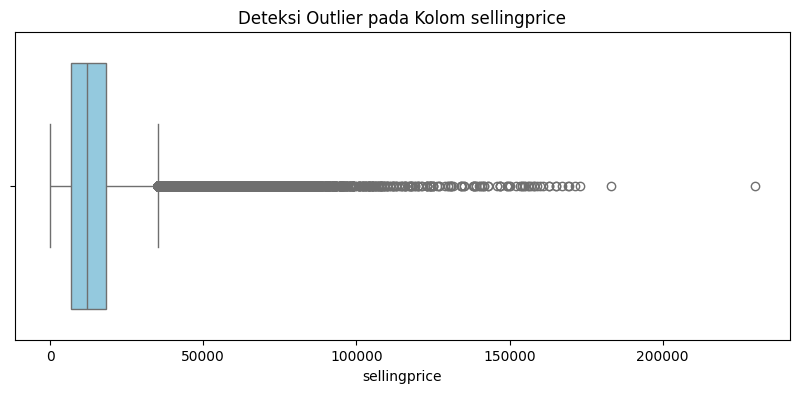

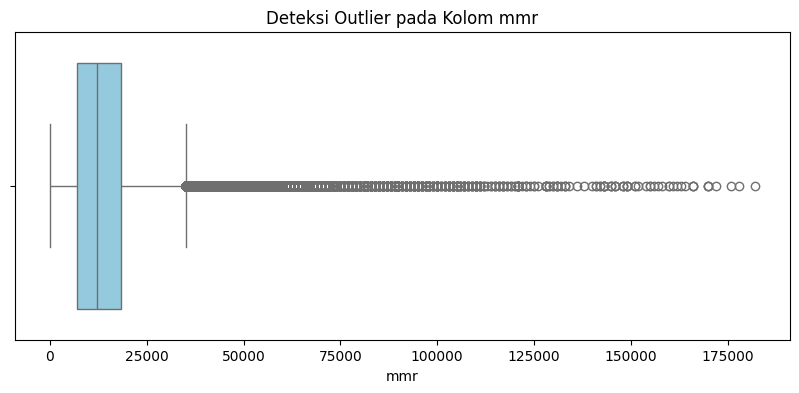

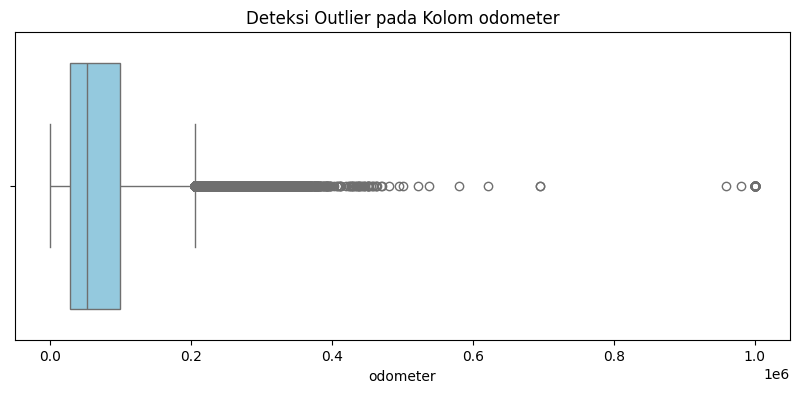

Jumlah outliers sellingprice: 14243
Jumlah outliers mmr: 3469
Jumlah outliers odometer: 8266
Jumlah data bersih: 446913


In [7]:
#outliers 
cols = ['sellingprice', 'mmr', 'odometer']
print(f"Jumlah data asli: {len(df_clean)}")

for col in cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col].dropna(), color='skyblue')
    plt.title(f'Deteksi Outlier pada Kolom {col}')
    plt.show()

for col in cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    IQR = q3 - q1
    lb = q1 - 1.5 * IQR
    ub = q3 + 1.5 * IQR
    #cari outliers
    outliers = df_clean[(df_clean[col] < lb) | (df_clean[col] > ub)]
    print(f"Jumlah outliers {col}: {len(outliers)}")
    #buang sisa
    df_clean = df_clean[(df_clean[col] >= lb) & (df_clean[col] <= ub)]

print(f"Jumlah data bersih: {len(df_clean)}")

## Derived Variables

In [8]:
df_clean['price_diff'] = df_clean['sellingprice'] - df_clean['mmr']
df_clean['car_age'] = 2026 - df_clean['year']

In [9]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
year,446913.0,2010.233965,3.715210,1990.0,2008.0,2012.0,2013.0,2015.0
condition,446913.0,3.417602,0.931774,1.0,2.7,3.6,4.2,5.0
odometer,446913.0,65087.072663,45762.927364,1.0,29029.0,52002.0,95723.0,202049.0
mmr,446913.0,12910.893395,7276.674180,25.0,7500.0,12150.0,17500.0,33000.0
sellingprice,446913.0,12761.485878,7395.314547,1.0,7250.0,12000.0,17500.0,34700.0
price_diff,446913.0,-149.407518,1584.940852,-31200.0,-800.0,-50.0,650.0,24050.0
car_age,446913.0,15.766035,3.715210,11.0,13.0,14.0,18.0,36.0


## Visualisasi Distribusi Data

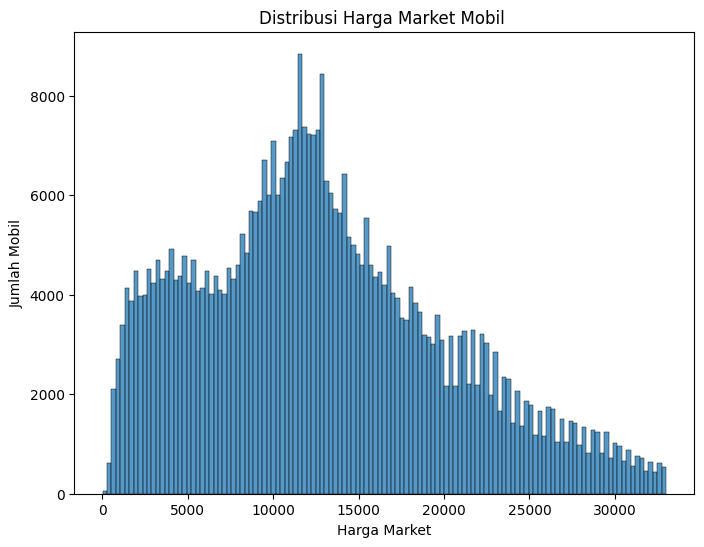

In [10]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clean, x='mmr')

plt.title('Distribusi Harga Market Mobil ')
plt.xlabel('Harga Market')
plt.ylabel('Jumlah Mobil')
plt.savefig("histogram.png", dpi=300)

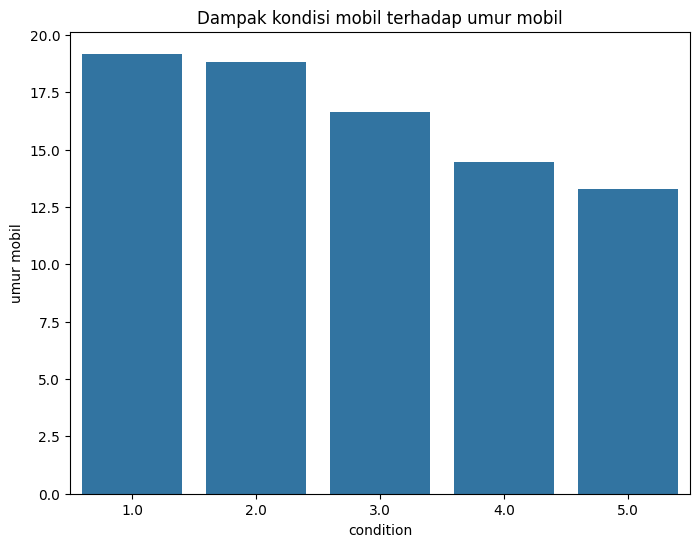

In [11]:
plt.figure(figsize=(8, 6))
#kolom sementara supaya lebih mudah visualisainya
df_clean['condition_rounded'] = df_clean['condition'].round()
sns.barplot(data=df_clean, x='condition_rounded', y='car_age', errorbar=None)

plt.title('Dampak kondisi mobil terhadap umur mobil')
plt.xlabel('condition')
plt.ylabel('umur mobil')
plt.savefig("barplot_condition_age.png", dpi=300)

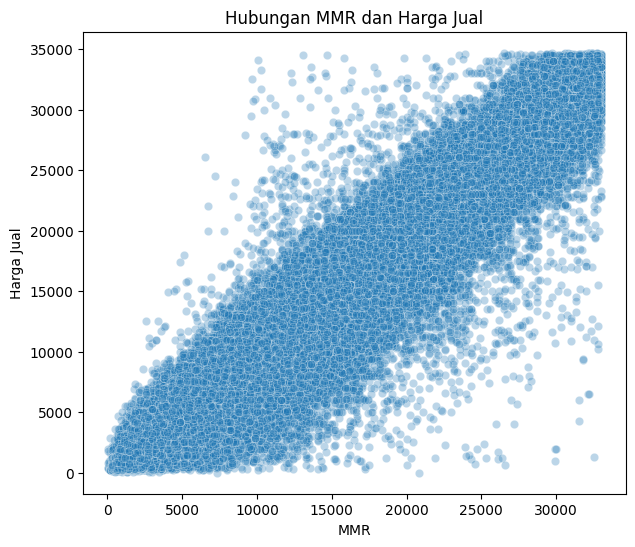

In [12]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_clean, x='mmr', y='sellingprice', alpha=0.3)

plt.title('Hubungan MMR dan Harga Jual')
plt.xlabel('MMR')
plt.ylabel('Harga Jual')
plt.savefig("scatterplot_mmr_sellingprice.png", dpi=300)

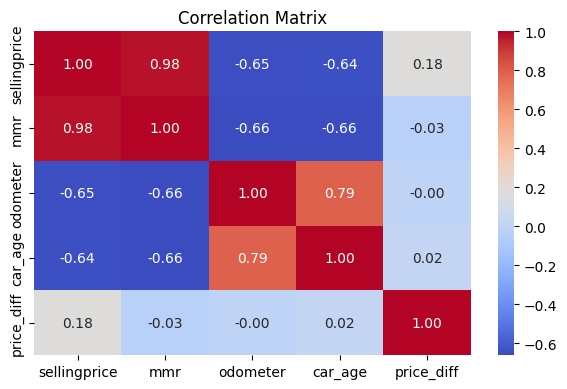

In [14]:
cols = ['sellingprice', 'mmr', 'odometer', 'car_age', 'price_diff']
plt.figure(figsize=(6,4))
sns.heatmap(df_clean[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)

## Export

In [17]:
df_clean['saledate'] = df_clean['saledate'].dt.tz_localize(None)
df_clean.to_excel('car_prices_clean.xlsx', index=False)